<a href="https://colab.research.google.com/github/jane-rusakova/python_for_hw_tasks/blob/main/HW_16_2_%D0%9F%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D0%BA%D1%80%D0%B5%D0%B4%D0%B8%D1%82%D0%BD%D0%BE%D0%B3%D0%BE_%D1%80%D0%B8%D0%B7%D0%B8%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.shape

(32581, 12)

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


In [7]:
df['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0,78.183604
1,21.816396


Датасет містить понад 32 000 записів позичальників та 12 ознак.
Цільова змінна loan_status є бінарною: 0 означає успішне погашення кредиту, 1 — дефолт.
Розподіл класів є нерівномірним: більшість клієнтів повертають кредит, тоді як частка дефолтів становить приблизно 20–25%.
Таким чином, задача є помірно незбалансованою класифікацією, що потребує використання метрик, чутливих до дисбалансу (precision, recall, F1-score, ROC-AUC).


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [10]:
df = pd.read_csv("credit_risk_dataset.csv")

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
loan_int_rate,9.563856
person_emp_length,2.747000
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


In [12]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-3075118698.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [13]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-2268294351.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
df[numeric_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


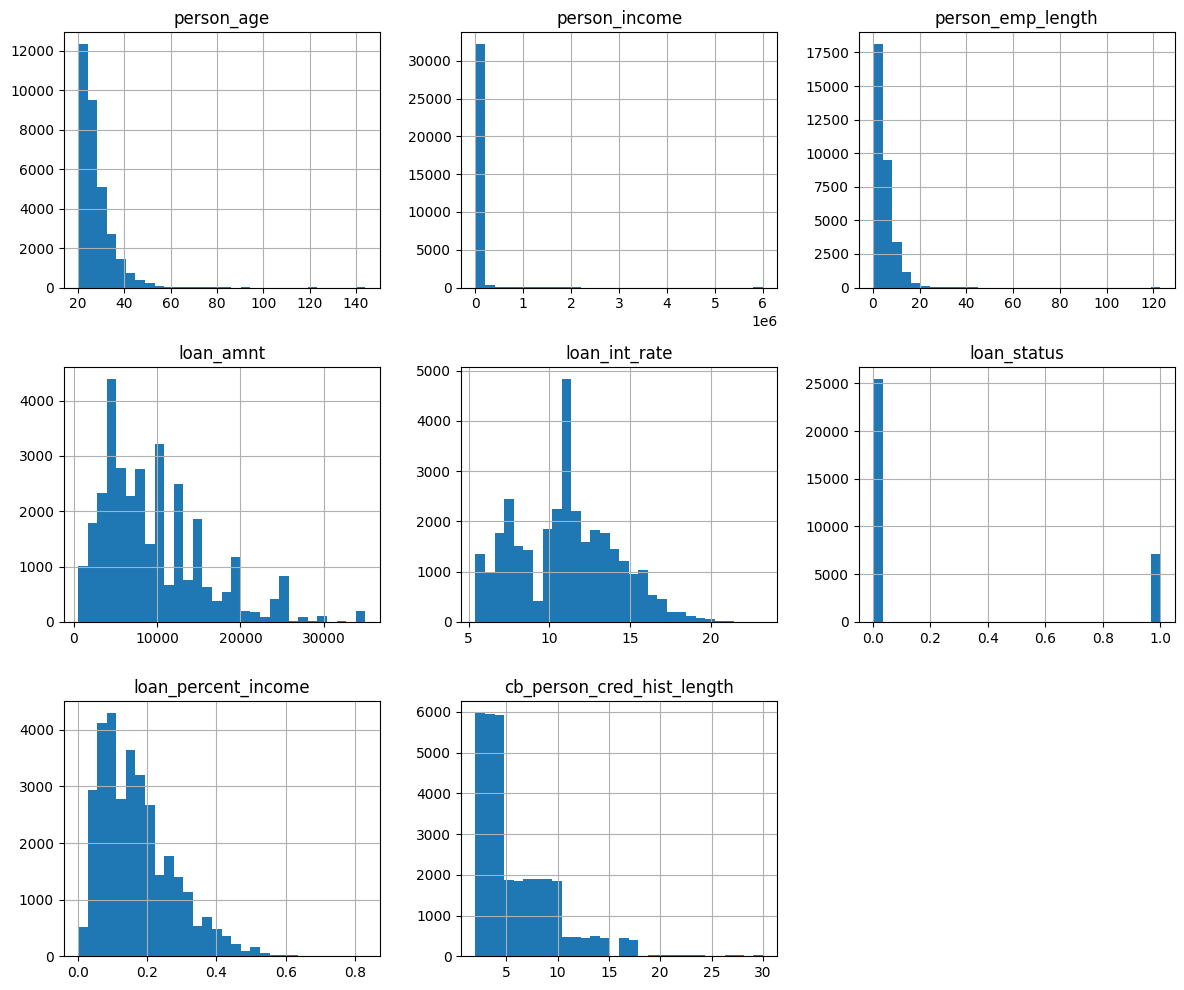

In [15]:
import matplotlib.pyplot as plt

df[numeric_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

In [16]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [17]:
df = df[(df['person_income'] >= lower_bound) &
        (df['person_income'] <= upper_bound)].copy()

Було виявлено екстремально великі значення доходу. Після застосування IQR-фільтрації дані стали більш стабільними для побудови моделі.

In [18]:
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 person_home_ownership
person_home_ownership
RENT        16102
MORTGAGE    12426
OWN          2469
OTHER         100
Name: count, dtype: int64

 loan_intent
loan_intent
EDUCATION            6201
MEDICAL              5846
VENTURE              5445
PERSONAL             5260
DEBTCONSOLIDATION    4955
HOMEIMPROVEMENT      3390
Name: count, dtype: int64

 loan_grade
loan_grade
A    10343
B     9924
C     6191
D     3459
E      899
F      221
G       60
Name: count, dtype: int64

 cb_person_default_on_file
cb_person_default_on_file
N    25626
Y     5471
Name: count, dtype: int64


In [19]:
for col in categorical_cols:
    print("\n", col)
    print(pd.crosstab(df[col], df['loan_status'], normalize='index'))


 person_home_ownership
loan_status                   0         1
person_home_ownership                    
MORTGAGE               0.871640  0.128360
OTHER                  0.680000  0.320000
OWN                    0.922236  0.077764
RENT                   0.680537  0.319463

 loan_intent
loan_status               0         1
loan_intent                          
DEBTCONSOLIDATION  0.709183  0.290817
EDUCATION          0.823899  0.176101
HOMEIMPROVEMENT    0.728024  0.271976
MEDICAL            0.728532  0.271468
PERSONAL           0.793916  0.206084
VENTURE            0.846281  0.153719

 loan_grade
loan_status         0         1
loan_grade                     
A            0.896645  0.103355
B            0.831016  0.168984
C            0.785010  0.214990
D            0.399248  0.600752
E            0.343715  0.656285
F            0.280543  0.719457
G            0.016667  0.983333

 cb_person_default_on_file
loan_status                       0         1
cb_person_default_on_file      

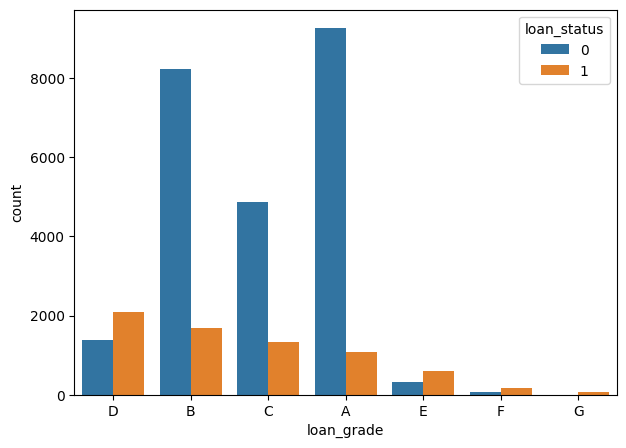

In [20]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.countplot(x='loan_grade', hue='loan_status', data=df)
plt.show()

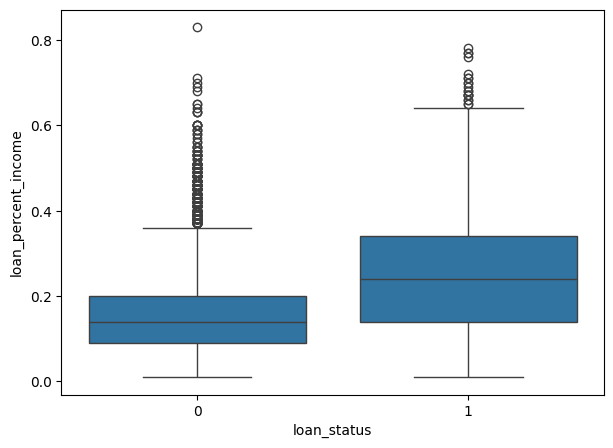

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.show()

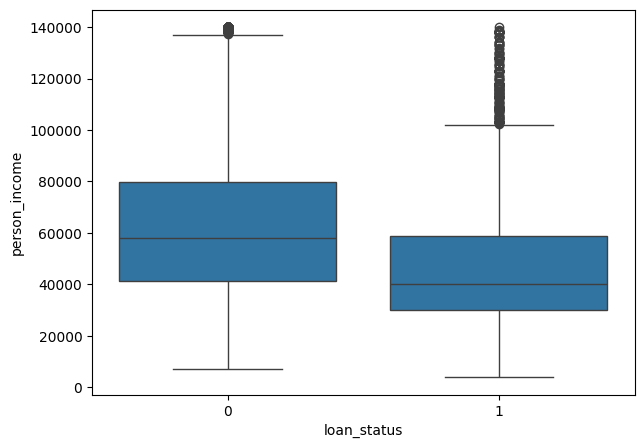

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.show()

Аналіз показав, що ключовими факторами кредитного ризику є кредитний рейтинг (loan_grade), співвідношення кредиту до доходу (loan_percent_income) та наявність попередніх дефолтів (cb_person_default_on_file).
Позичальники з низьким рейтингом (E–F) значно частіше допускають дефолт.
Вищий loan_percent_income пов’язаний із суттєвим зростанням ймовірності дефолту.
Таким чином, дані демонструють логічні та економічно обґрунтовані залежності.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [23]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [24]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.081485,0.155934,0.036407,0.009655,-0.016522,-0.023383,0.869909
person_income,0.081485,1.000000,0.188611,0.385604,-0.034314,-0.254228,-0.329516,0.057592
person_emp_length,0.155934,0.188611,1.000000,0.103383,-0.056518,-0.082116,-0.041463,0.134844
loan_amnt,0.036407,0.385604,0.103383,1.000000,0.130542,0.123433,0.642413,0.025947
loan_int_rate,0.009655,-0.034314,-0.056518,0.130542,1.000000,0.320203,0.119758,0.014897
loan_status,-0.016522,-0.254228,-0.082116,0.123433,0.320203,1.000000,0.379806,-0.010769
loan_percent_income,-0.023383,-0.329516,-0.041463,0.642413,0.119758,0.379806,1.000000,-0.014664
cb_person_cred_hist_length,0.869909,0.057592,0.134844,0.025947,0.014897,-0.010769,-0.014664,1.000000


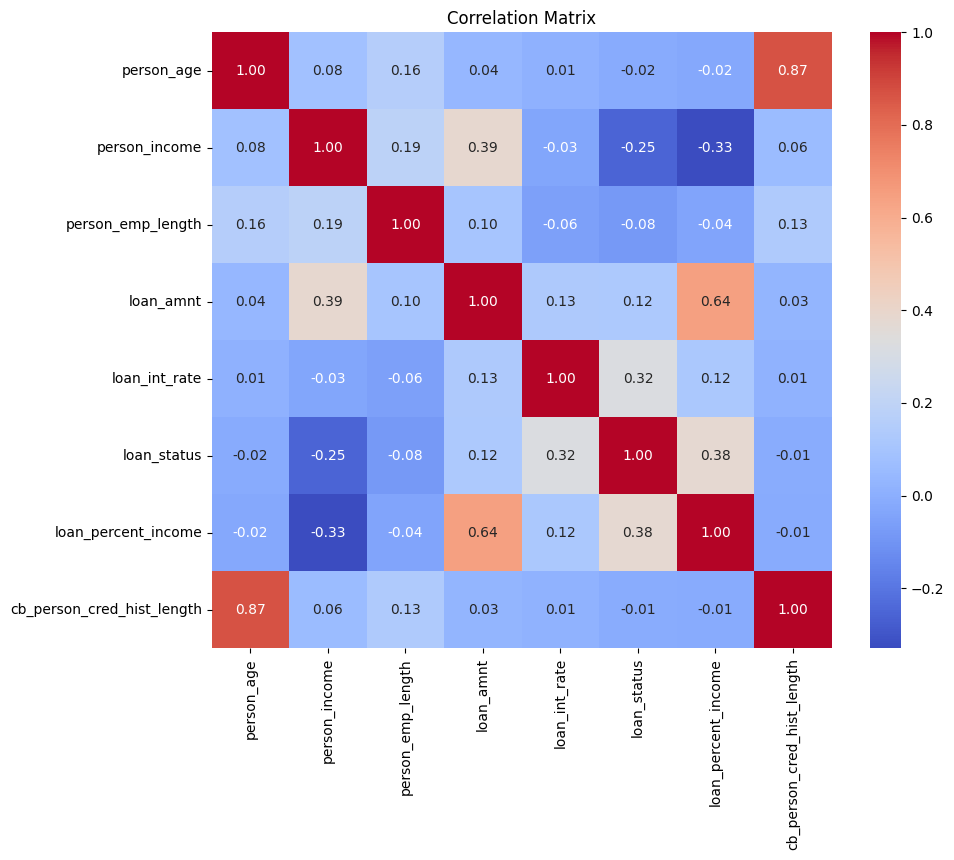

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [26]:
corr_matrix['loan_status'].sort_values(ascending=False)

,loan_status
loan_status,1.000000
loan_percent_income,0.379806
loan_int_rate,0.320203
loan_amnt,0.123433
cb_person_cred_hist_length,-0.010769
person_age,-0.016522
person_emp_length,-0.082116
person_income,-0.254228


In [27]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [28]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [29]:
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

Було побудовано матрицю кореляцій для числових змінних. Найбільший позитивний зв’язок із дефолтом продемонструвала змінна loan_percent_income, що є економічно логічним результатом.
Категоріальні змінні були закодовані методом One-Hot Encoding.
У фінальну модель включено всі ознаки, оскільки вони мають економічне обґрунтування та не демонструють критичної мультиколінеарності.


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [30]:
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# визначаємо числові колонки
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# fit тільки на train
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# transform test
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [35]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [36]:
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


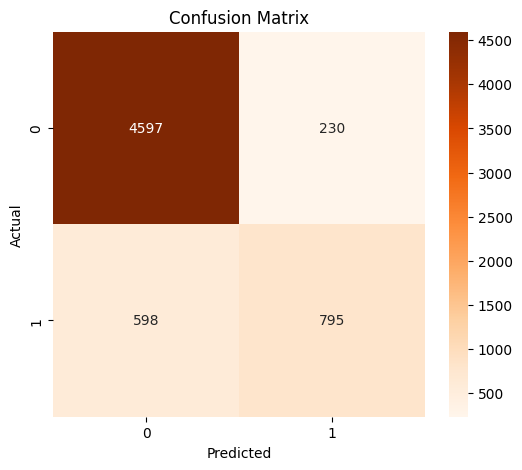

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8668810289389067
Precision: 0.775609756097561
Recall: 0.5707106963388371
F1-score: 0.6575682382133995


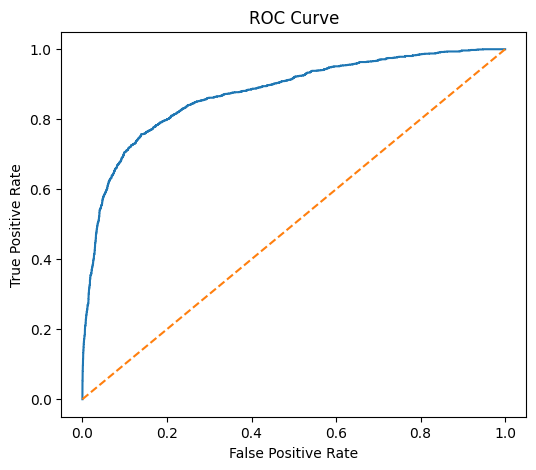

ROC-AUC: 0.874421978191291


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC:", auc_score)

In [42]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])

coefficients = coefficients.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Abs_Coefficient
20,loan_grade_G,4.311818,4.311818
19,loan_grade_F,2.742544,2.742544
18,loan_grade_E,2.498114,2.498114
17,loan_grade_D,2.332286,2.332286
8,person_home_ownership_OWN,-1.655919,1.655919
5,loan_percent_income,1.310677,1.310677
14,loan_intent_VENTURE,-1.048438,1.048438
10,loan_intent_EDUCATION,-0.811300,0.811300
9,person_home_ownership_RENT,0.808080,0.808080
13,loan_intent_PERSONAL,-0.593571,0.593571


Модель логістичної регресії продемонструвала високу якість класифікації.

ROC-AUC становить 0.87, що свідчить про дуже хорошу здатність моделі розрізняти дефолтних та надійних позичальників.

Аналіз коефіцієнтів показав, що найбільший вплив на ймовірність дефолту мають:

Кредитний рейтинг (loan_grade)

Співвідношення кредиту до доходу (loan_percent_income)

Тип володіння житлом (person_home_ownership)

Історія попередніх дефолтів

Позичальники з низьким кредитним рейтингом (D–G), високим співвідношенням кредиту до доходу та історією дефолтів мають значно вищу ймовірність неповернення кредиту.

Модель демонструє економічно логічні закономірності та може бути використана як базовий інструмент оцінки кредитного ризику.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [44]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for t in thresholds:
    y_pred_threshold = (y_test_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
results_df

,Threshold,Precision,Recall,F1
0,0.2,0.530389,0.801866,0.638468
1,0.3,0.627306,0.732233,0.675720
2,0.4,0.710404,0.656856,0.682581
3,0.5,0.775610,0.570711,0.657568
4,0.6,0.806008,0.462312,0.587591
5,0.7,0.841567,0.354630,0.498990


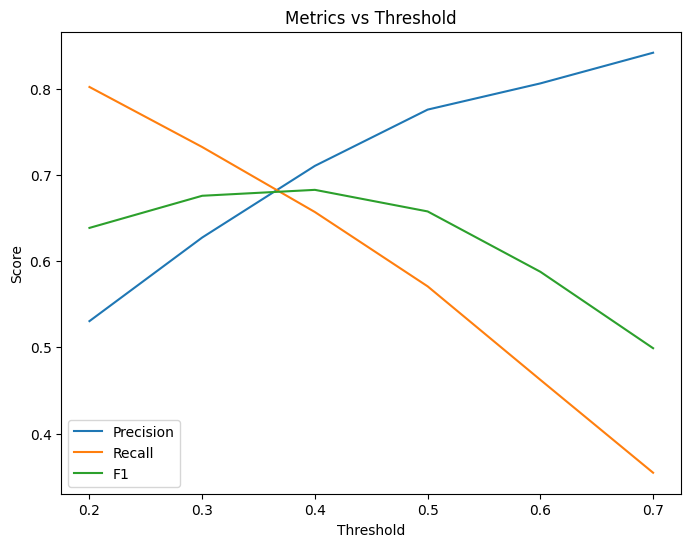

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall")
plt.plot(results_df["Threshold"], results_df["F1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics vs Threshold")
plt.legend()
plt.show()

Було проаналізовано зміну метрик precision, recall та F1 при різних порогах класифікації.

Зі зменшенням порогу зростає recall (модель знаходить більше дефолтів), але зменшується precision (зростає кількість хибних спрацьовувань).

Максимальне значення F1-score досягнуто при порозі 0.4, що забезпечує оптимальний баланс між precision та recall.

Оскільки для банку більш критично мінімізувати пропущені дефолти (False Negatives), доцільно обрати поріг 0.4, який дозволяє суттєво підвищити recall у порівнянні зі стандартним порогом 0.5.

Таким чином, модель може бути адаптована під бізнес-цілі шляхом регулювання порогу прийняття рішення.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

dt_auc = roc_auc_score(y_test, dt_proba)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree AUC:", dt_auc)
print("Decision Tree F1:", dt_f1)

Decision Tree AUC: 0.8466837725280343
Decision Tree F1: 0.759800427655025


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_proba)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest AUC:", rf_auc)
print("Random Forest F1:", rf_f1)

Random Forest AUC: 0.9298363729625071
Random Forest F1: 0.8184438040345822


In [48]:
log_auc = auc_score
log_f1 = f1_score(y_test, y_test_pred)

In [49]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "ROC-AUC": [log_auc, dt_auc, rf_auc],
    "F1-score": [log_f1, dt_f1, rf_f1]
})

comparison

,Model,ROC-AUC,F1-score
0,Logistic Regression,0.874422,0.657568
1,Decision Tree,0.846684,0.759800
2,Random Forest,0.929836,0.818444


Було навчено три моделі: Logistic Regression, Decision Tree та Random Forest.

Найкращий результат продемонструвала модель Random Forest, яка показала:

ROC-AUC ≈ 0.93

F1-score ≈ 0.82

Це свідчить про високу здатність моделі розрізняти дефолтних та надійних позичальників.

Logistic Regression показала стабільний результат (ROC-AUC ≈ 0.87), однак поступається Random Forest за якістю класифікації.

Decision Tree продемонструвала гірший ROC-AUC та нижчу стабільність.

Таким чином, для задачі прогнозування кредитного ризику найефективнішою моделлю є Random Forest, тоді як Logistic Regression має перевагу з точки зору інтерпретованості.